# SimPEG Two-Stage Magnetisation Vector Inversion (MVI)
## Remnantly Charged UXO — Synthetic Data & Inversion


In [386]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle

from discretize import TensorMesh
from simpeg import (
    maps,
    data as sdata,
    data_misfit,
    regularization,
    optimization,
    inversion,
    inverse_problem,
    directives,
)
from simpeg.potential_fields import magnetics

#  constants 
mu0  = 4 * np.pi * 1e-7   
nT2T = 1e-9               



## 2. Helper functions

In [387]:
def unit_vec(inc_deg, dec_deg):
    i, d = np.deg2rad(inc_deg), np.deg2rad(dec_deg)
    return np.array([np.cos(i)*np.cos(d), np.cos(i)*np.sin(d), np.sin(i)])

def vec_inc_dec(mx, my, mz):
    amp = np.sqrt(mx**2 + my**2 + mz**2)
    amp = np.where(amp == 0, 1e-30, amp)
    inc = np.rad2deg(np.arcsin(np.clip(mz / amp, -1, 1)))
    dec = np.rad2deg(np.arctan2(my, mx))
    return inc, dec


## 3. Earth field & receiver survey

We place 101 TMI receivers at 1 m above the surface along a 50-m east–west profile.
Earth field parameters are representative of a mid-latitude Canadian site.


In [388]:
# Earths field
B0_amp, B0_inc, B0_dec = 55000., 70., 15.  
B0_hat = unit_vec(B0_inc, B0_dec)

# Receiver locations
n_rx      = 101
x_rx      = np.linspace(-25, 25, n_rx)
recv_locs = np.c_[x_rx, np.zeros(n_rx), np.ones(n_rx)]

# Survey
rxs_tmi  = magnetics.receivers.Point(recv_locs, components=["tmi"])
src_tmi  = magnetics.sources.UniformBackgroundField(
    [rxs_tmi], amplitude=B0_amp, inclination=B0_inc, declination=B0_dec)
surv_tmi = magnetics.survey.Survey(src_tmi)



## 4. Tensor mesh

This cell builds a **thin 3-D mesh** (1 cell in Y) to represent the 2-D cross-section.
SimPEG's `Simulation3DIntegral` requires a 3-D mesh even for a profile survey.

- Core cell size: 0.5 m × 1 m × 0.5 m  
- Padding: 7 cells on each side with an expansion factor of 1.5


In [389]:
dx, dz   = 0.5, 0.5     
dy       = 1.0           
ncore_x, ncore_z = 120, 40
npad_x,  npad_z  =   7,  7

hx = [(dx, npad_x, -1.5), (dx, ncore_x), (dx, npad_x, 1.5)]
hy = [(dy, 1)]
hz = [(dz, npad_z, -1.5), (dz, ncore_z)]

mesh = TensorMesh([hx, hy, hz], origin="CC0")
mesh.origin = np.r_[mesh.origin[0], mesh.origin[1], -mesh.h[2].sum()]

print(f"Mesh shape : {mesh.shape_cells}  ({mesh.nC:,} cells)")
print(f"X extent   : {mesh.nodes_x[0]:.1f} -> {mesh.nodes_x[-1]:.1f} m")
print(f"Z extent   : {mesh.nodes_z[0]:.1f} -> {mesh.nodes_z[-1]:.1f} m")


Mesh shape : (134, 1, 47)  (6,298 cells)
X extent   : -54.1 -> 54.1 m
Z extent   : -44.1 -> 0.0 m


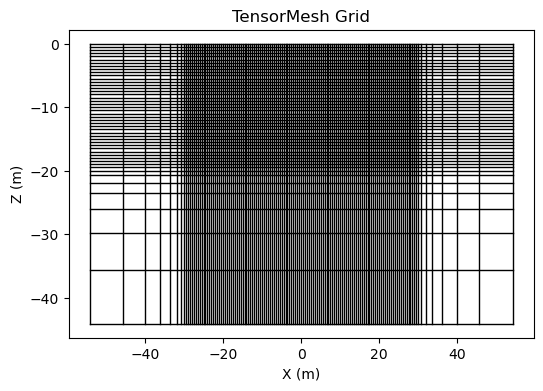

In [390]:
# Tensormesh plot

fig, ax = plt.subplots(1, 1, figsize=(6, 4))


for x in mesh.nodes_x:
    ax.plot([x, x], [mesh.nodes_z.min(), mesh.nodes_z.max()], color="k", linewidth=1)


for z in mesh.nodes_z:
    ax.plot([mesh.nodes_x.min(), mesh.nodes_x.max()], [z, z], color="k", linewidth=1)

ax.set_title("TensorMesh Grid")
ax.set_xlabel("X (m)")
ax.set_ylabel("Z (m)")

plt.show()

## 5. True magnetisation model

In [391]:
# UXO parameters
chi_bg, chi_uxo = 1e-5, 0.05
uxo_cx, uxo_cz  = 0., -3.
uxo_dx, uxo_dz  = 3., 1.5

# Remanent direction 
rem_inc, rem_dec = -40, 200.
rem_M            =  8.         # A/m

# Active cells
cc     = mesh.cell_centers
active = cc[:, 2] < 0.
n_act  = int(active.sum())
cc_act = cc[active]

in_uxo = (
    (np.abs(cc_act[:, 0] - uxo_cx) <= uxo_dx / 2) &
    (np.abs(cc_act[:, 2] - uxo_cz) <= uxo_dz / 2)
)

B0_T     = B0_amp * nT2T
M_ind_bg = chi_bg  * B0_T / mu0
M_ind_ux = chi_uxo * B0_T / mu0
rem_hat  = unit_vec(rem_inc, rem_dec)

m_true = np.zeros(3 * n_act)

# Background
m_true[:n_act]        = M_ind_bg * B0_hat[0]
m_true[n_act:2*n_act] = M_ind_bg * B0_hat[1]
m_true[2*n_act:]      = M_ind_bg * B0_hat[2]

# UXO:
m_true[:n_act][in_uxo]          = M_ind_ux * B0_hat[0]  
m_true[n_act:2*n_act][in_uxo]   = M_ind_ux * B0_hat[1]
m_true[2*n_act:][in_uxo]        = M_ind_ux * B0_hat[2]

# UXO:
m_true[:n_act][in_uxo]          += rem_M * rem_hat[0]
m_true[n_act:2*n_act][in_uxo]   += rem_M * rem_hat[1]
m_true[2*n_act:][in_uxo]        += rem_M * rem_hat[2]

# Derived quantities for plotting / reporting
M_amp_true   = np.sqrt(m_true[:n_act]**2 + m_true[n_act:2*n_act]**2 + m_true[2*n_act:]**2)
M_amp_uxo    = M_amp_true[in_uxo].mean()
inc_true, dec_true = vec_inc_dec(m_true[:n_act], m_true[n_act:2*n_act], m_true[2*n_act:])

print(f"Active cells          : {n_act:,}")
print(f"UXO cells             : {in_uxo.sum()}")
print(f"Induced  |M| in UXO   : {M_ind_ux:.3f} A/m  (inc={B0_inc}°, dec={B0_dec}°)")
print(f"Remanent |M| in UXO   : {rem_M:.3f} A/m  (inc={rem_inc}°, dec={rem_dec}°)")
print(f"Total    |M| in UXO   : {M_amp_uxo:.3f} A/m  (inc={inc_true[in_uxo].mean():.1f}°, dec={dec_true[in_uxo].mean():.1f}°)")


Active cells          : 6,298
UXO cells             : 24
Induced  |M| in UXO   : 2.188 A/m  (inc=70.0°, dec=15.0°)
Remanent |M| in UXO   : 8.000 A/m  (inc=-40°, dec=200.0°)
Total    |M| in UXO   : 6.205 A/m  (inc=-29.8°, dec=-159.3°)


## 6. Forward simulations & synthetic data


In [392]:
# Maps
act_map_sc = maps.InjectActiveCells(mesh, active, 0.)         
wires      = maps.Wires(("mx", n_act), ("my", n_act), ("mz", n_act))

# scalar simulation
sim_sc = magnetics.simulation.Simulation3DIntegral(
    survey=surv_tmi, mesh=mesh, model_type="scalar",
    chiMap=act_map_sc, active_cells=active,
)

# MVI simulation 
sim_mvi = magnetics.simulation.Simulation3DIntegral(
    survey=surv_tmi, mesh=mesh, model_type="vector",
    chiMap=maps.IdentityMap(nP=3 * n_act), active_cells=active,
)

d_true = sim_mvi.dpred(m_true)

#noise
rng   = np.random.default_rng(42)
sigma = 0.02 * np.abs(d_true) + 0.5
d_obs = d_true + rng.normal(0, sigma)

data_obj = sdata.Data(surv_tmi, dobs=d_obs, standard_deviation=sigma)


## 7. Visualise survey geometry & true model

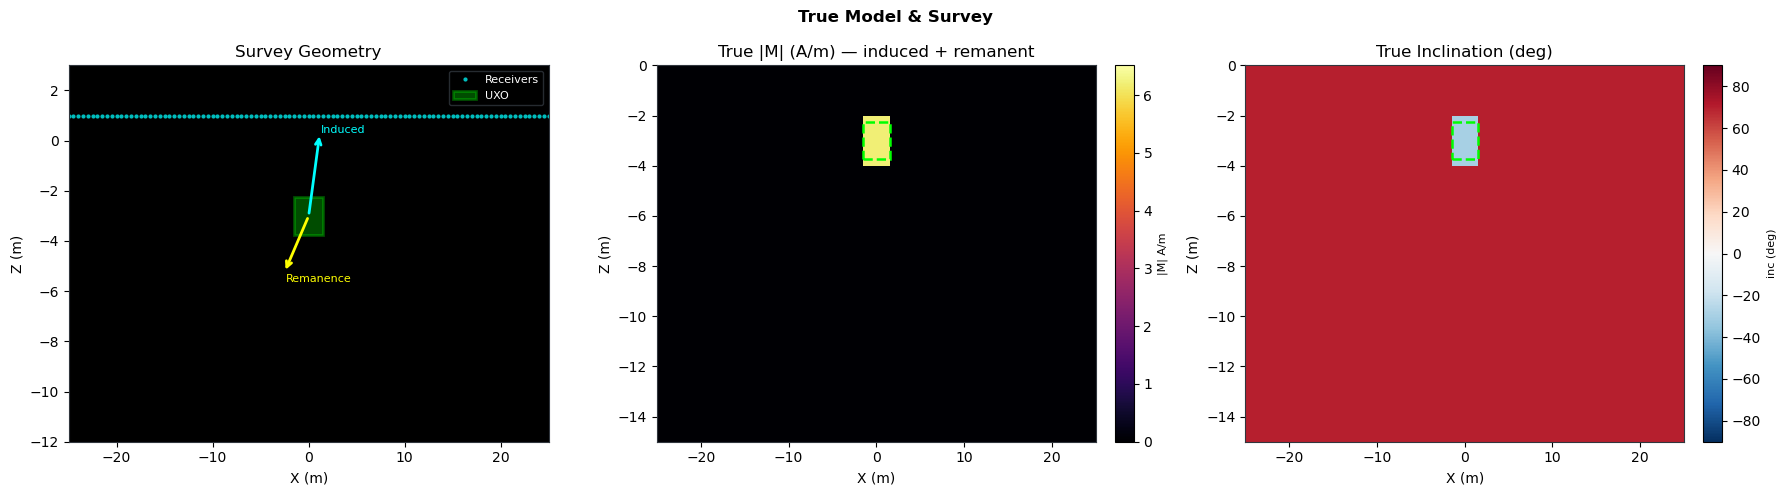

In [393]:
def xz_slice(mf, mesh=mesh, active=active, n_act=n_act):
    if mf.shape[0] == n_act:
        tmp = np.zeros(mesh.nC); tmp[active] = mf; mf = tmp
    return mf.reshape(mesh.shape_cells, order="F")[:, 0, :].T

xi = np.where((mesh.cell_centers_x >= -25) & (mesh.cell_centers_x <= 25))[0]
zi = np.where((mesh.cell_centers_z >= -15) & (mesh.cell_centers_z <= 0))[0]
xc, zc = mesh.cell_centers_x[xi], mesh.cell_centers_z[zi]
crop   = lambda arr: xz_slice(arr)[np.ix_(zi, xi)]

bg = "k"
def sax(ax):
    ax.set_facecolor(bg); ax.tick_params(colors="k")
    for s in ax.spines.values(): s.set_edgecolor("#30363d")
def cbar(fig, ax, im, lbl):
    cb = fig.colorbar(im, ax=ax, fraction=.046, pad=.04)
    cb.set_label(lbl, color="k", fontsize=8)
    cb.ax.yaxis.set_tick_params(color="k")
    plt.setp(cb.ax.yaxis.get_ticklabels(), color="k")
def uxo_box(ax):
    ax.add_patch(Rectangle((uxo_cx-uxo_dx/2, uxo_cz-uxo_dz/2), uxo_dx, uxo_dz,
        lw=1.8, ec="lime", fc="none", ls="--", zorder=5))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
#fig.patch.set_facecolor("#0d1117")

# Geometry
ax = axes[0]; sax(ax)
ax.plot(x_rx, recv_locs[:, 2], "c.", ms=4, label="Receivers")
ax.add_patch(Rectangle((uxo_cx-uxo_dx/2, uxo_cz-uxo_dz/2), uxo_dx, uxo_dz,
    lw=2, ec="lime", fc="lime", alpha=.3, label="UXO"))
sc = 3.5
ax.annotate("", xy=(uxo_cx + B0_hat[0]*sc, uxo_cz + B0_hat[2]*sc),
    xytext=(uxo_cx, uxo_cz), arrowprops=dict(arrowstyle="->", color="cyan", lw=2))
ax.text(uxo_cx + B0_hat[0]*sc + .1, uxo_cz + B0_hat[2]*sc, "Induced", color="cyan", fontsize=8)
rv = unit_vec(rem_inc, rem_dec)
ax.annotate("", xy=(uxo_cx + rv[0]*sc, uxo_cz + rv[2]*sc),
    xytext=(uxo_cx, uxo_cz), arrowprops=dict(arrowstyle="->", color="yellow", lw=2))
ax.text(uxo_cx + rv[0]*sc + .1, uxo_cz + rv[2]*sc - .4, "Remanence", color="yellow", fontsize=8)
ax.set_xlim(-25, 25); ax.set_ylim(-12, 3)
ax.set_xlabel("X (m)", color="k"); ax.set_ylabel("Z (m)", color="k")
ax.set_title("Survey Geometry", color="k")
ax.legend(fontsize=8, labelcolor="w", facecolor=bg, edgecolor="#30363d")

# True |M|
ax = axes[1]; sax(ax)
im = ax.pcolormesh(xc, zc, crop(M_amp_true), cmap="inferno",
    vmin=0, vmax=M_amp_uxo*1.05)
uxo_box(ax); ax.set_xlim(-25,25); ax.set_ylim(-15,0)
ax.set_xlabel("X (m)", color="k"); ax.set_ylabel("Z (m)", color="k")
ax.set_title("True |M| (A/m) — induced + remanent", color="k")
cbar(fig, ax, im, "|M| A/m")

# True inc
ax = axes[2]; sax(ax)
im = ax.pcolormesh(xc, zc, crop(inc_true), cmap="RdBu_r",
    vmin=-90, vmax=90, shading="auto")
uxo_box(ax); ax.set_xlim(-25,25); ax.set_ylim(-15,0)
ax.set_xlabel("X (m)", color="k"); ax.set_ylabel("Z (m)", color="k")
ax.set_title("True Inclination (deg)", color="k")
cbar(fig, ax, im, "inc (deg)")

fig.suptitle("True Model & Survey", color="k", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


## 8. Synthetic TMI data

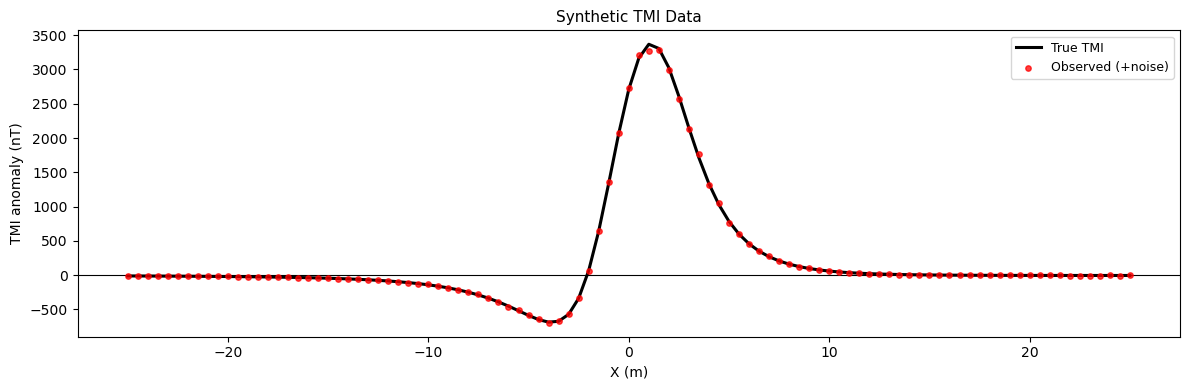

In [394]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(x_rx, d_true, color="k", lw=2.2, label="True TMI")
ax.scatter(x_rx, d_obs, s=15, color="red", alpha=.75, zorder=5, label="Observed (+noise)")
ax.axhline(0, color="k", lw=.8)
ax.set_xlabel("X (m)", color="k"); ax.set_ylabel("TMI anomaly (nT)", color="k")
ax.set_title("Synthetic TMI Data", color="k", fontsize=11)
ax.legend(fontsize=9, labelcolor="k")
plt.tight_layout(); plt.show()


## 9. Stage 1 — Scalar susceptibility inversion

In [395]:
m0_sc   = np.full(n_act, chi_bg)
dmis_sc = data_misfit.L2DataMisfit(data=data_obj, simulation=sim_sc)
reg_sc  = regularization.WeightedLeastSquares(
    mesh, active_cells=active,
    alpha_s=1e-3, alpha_x=1., alpha_y=1., alpha_z=1.)
opt_sc  = optimization.InexactGaussNewton(maxIter=30, maxIterCG=40, tolCG=1e-5)
invp_sc = inverse_problem.BaseInvProblem(dmis_sc, reg_sc, opt_sc)

dl_sc = [
    directives.BetaEstimate_ByEig(beta0_ratio=1.),
    directives.BetaSchedule(coolingFactor=2, coolingRate=1),
    directives.TargetMisfit(chifact=1.),
    directives.SaveOutputEveryIteration(save_txt=False),
]
inv_sc = inversion.BaseInversion(invp_sc, directiveList=dl_sc)
m_sc   = inv_sc.run(m0_sc)

phi_d_sc  = np.array(dl_sc[3].phi_d)
phi_m_sc  = np.array(dl_sc[3].phi_m)
d_pred_sc = sim_sc.dpred(m_sc)
r2_sc     = np.corrcoef(d_obs, d_pred_sc)[0, 1]**2

print(f"  phi_d = {phi_d_sc[-1]:.1f}  (target ~ {n_rx})")
print(f"  iters = {len(phi_d_sc)}")
print(f"  R²    = {r2_sc:.4f}")
print(f"  Peak chi recovered = {m_sc.max():.4f}  (true = {chi_uxo})")


INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: 
simpeg.InvProblem is setting bfgsH0 to the inverse of the reg.deriv2.
using the default solver Mumps with the 'is_symmetric=True` option set.

INFO: Directive TargetMisfit: Target data misfit is 101.0



Running inversion with SimPEG v0.25.0
============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  3.32e+05  1.17e+05  7.22e-41  1.17e+05                                 
   1  3.32e+05  2.52e+04  3.16e-02  3.57e+04    7.76e+05      0              
   2  1.66e+05  1.83e+04  6.14e-02  2.85e+04    2.05e+04      0   Skip BFGS  
   3  8.29e+04  1.23e+04  1.13e-01  2.17e+04    1.39e+04      0   Skip BFGS  
   4  4.14e+04  7.45e+03  1.95e-01  1.55e+04    1.30e+04      0   Skip BFGS  
   5  2.07e+04  4.06e+03  3.08e-01  1.04e+04    1.48e+04      0   Skip BFGS  
   6  1.04e+04  1.97e+03  4.42e-01  6.55e+03    1.86e+04      0   Skip BFGS  
   7  5.18e+03  8.41e+02  5.79e-01  3.84e+03    1.02e+04      0   Skip BFGS  
   8  2.59e+03  4.80e+02  6.62e-01  2.19e+03    9.47e+03      0   Skip BFGS  
   9  1.30e+03  3.43e+02

### 9a. Convert Stage-1 result to focusing weights


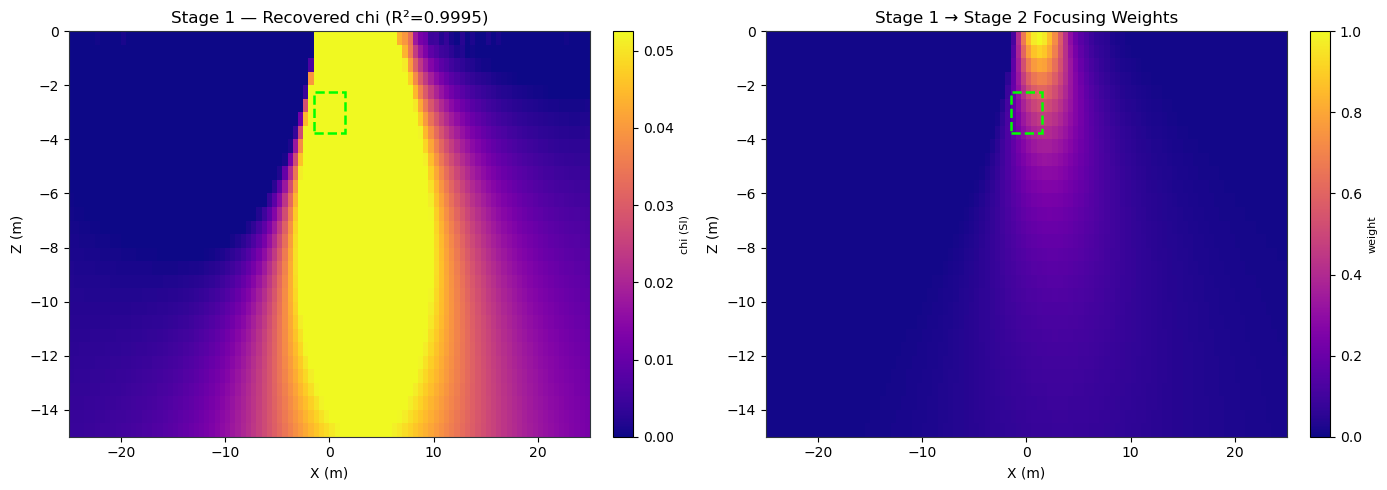

In [396]:
# M amplitude from scalar result
M_sc    = m_sc * B0_T / mu0           # A/m
M_sc    = np.clip(M_sc, 0, None)

# Normalise to [0.01, 1]
w_focus = np.clip(M_sc / (M_sc.max() + 1e-12), 1e-2, 1.)

# Plot weight map
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


ax = axes[0]; sax(ax)
im = ax.pcolormesh(xc, zc, crop(act_map_sc * m_sc), cmap="plasma",
    vmin=0, vmax=chi_uxo*1.05, shading="auto")
uxo_box(ax); ax.set_xlim(-25,25); ax.set_ylim(-15,0)
ax.set_xlabel("X (m)", color="k"); ax.set_ylabel("Z (m)", color="k")
ax.set_title(f"Stage 1 — Recovered chi (R²={r2_sc:.4f})", color="k")
cbar(fig, ax, im, "chi (SI)")

ax = axes[1]; sax(ax)
im = ax.pcolormesh(xc, zc, crop(w_focus), cmap="plasma", vmin=0, vmax=1, shading="auto")
uxo_box(ax); ax.set_xlim(-25,25); ax.set_ylim(-15,0)
ax.set_xlabel("X (m)", color="k"); ax.set_ylabel("Z (m)", color="k")
ax.set_title("Stage 1 → Stage 2 Focusing Weights", color="k")
cbar(fig, ax, im, "weight")

plt.tight_layout(); plt.show()


## 10. Stage 2 — Magnetisation Vector Inversion (MVI)

In [397]:
m0_mvi   = np.zeros(3 * n_act)
dmis_mvi = data_misfit.L2DataMisfit(data=data_obj, simulation=sim_mvi)

def make_reg_mvi(wire_map):
    """L2 regularisation for one M component, with Stage-1 focussing weights."""
    r = regularization.WeightedLeastSquares(
        mesh, active_cells=active, mapping=wire_map,
        alpha_s=5e-4, alpha_x=1., alpha_y=1., alpha_z=1.)
    r.set_weights(amplitude=w_focus)   # spatial focussing from Stage 1
    return r

reg_mvi  = make_reg_mvi(wires.mx) + make_reg_mvi(wires.my) + make_reg_mvi(wires.mz)
opt_mvi  = optimization.InexactGaussNewton(maxIter=40, maxIterCG=60, tolCG=1e-5)
invp_mvi = inverse_problem.BaseInvProblem(dmis_mvi, reg_mvi, opt_mvi)

dl_mvi = [
    directives.BetaEstimate_ByEig(beta0_ratio=157),
    directives.BetaSchedule(coolingFactor=2, coolingRate=1),
    directives.TargetMisfit(chifact=1.),
    directives.SaveOutputEveryIteration(save_txt=False),
]
inv_mvi = inversion.BaseInversion(invp_mvi, directiveList=dl_mvi)
m_mvi   = inv_mvi.run(m0_mvi)

phi_d_mvi  = np.array(dl_mvi[3].phi_d)
phi_m_mvi  = np.array(dl_mvi[3].phi_m)
d_pred_mvi = sim_mvi.dpred(m_mvi)
r2_mvi     = np.corrcoef(d_obs, d_pred_mvi)[0, 1]**2

# Derived MVI quantities
mx_r, my_r, mz_r = m_mvi[:n_act], m_mvi[n_act:2*n_act], m_mvi[2*n_act:]
M_amp_rec         = np.sqrt(mx_r**2 + my_r**2 + mz_r**2)
inc_rec, dec_rec  = vec_inc_dec(mx_r, my_r, mz_r)

print(f"  phi_d = {phi_d_mvi[-1]:.1f}  (target ~ {n_rx})")
print(f"  iters = {len(phi_d_mvi)}")
print(f"  R²    = {r2_mvi:.4f}")
print(f"  Peak |M| recovered  = {M_amp_rec.max():.3f} A/m  (true = {M_amp_uxo:.3f} A/m)")
print(f"  UXO inc  rec / true = {inc_rec[in_uxo].mean():.1f}° / {inc_true[in_uxo].mean():.1f}°")
print(f"  UXO dec  rec / true = {dec_rec[in_uxo].mean():.1f}° / {dec_true[in_uxo].mean():.1f}°")


INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: 
simpeg.InvProblem is setting bfgsH0 to the inverse of the reg.deriv2.
using the default solver Mumps with the 'is_symmetric=True` option set.

INFO: Directive TargetMisfit: Target data misfit is 101.0



Running inversion with SimPEG v0.25.0
============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  9.91e+08  1.17e+05  0.00e+00  1.17e+05                                 
   1  9.91e+08  6.44e+04  9.19e-06  7.35e+04    1.00e+06      0              
   2  4.96e+08  5.77e+04  1.89e-05  6.71e+04    9.21e+04      0   Skip BFGS  
   3  2.48e+08  5.09e+04  3.86e-05  6.05e+04    7.31e+04      0   Skip BFGS  
   4  1.24e+08  4.42e+04  7.78e-05  5.38e+04    5.79e+04      0   Skip BFGS  
   5  6.20e+07  3.76e+04  1.54e-04  4.72e+04    4.57e+04      0   Skip BFGS  
   6  3.10e+07  3.14e+04  2.98e-04  4.06e+04    3.60e+04      0   Skip BFGS  
   7  1.55e+07  2.57e+04  5.62e-04  3.44e+04    2.83e+04      0   Skip BFGS  
   8  7.75e+06  2.06e+04  1.03e-03  2.86e+04    2.23e+04      0   Skip BFGS  
   9  3.87e+06  1.62e+04

## 11. Stage-2 MVI results

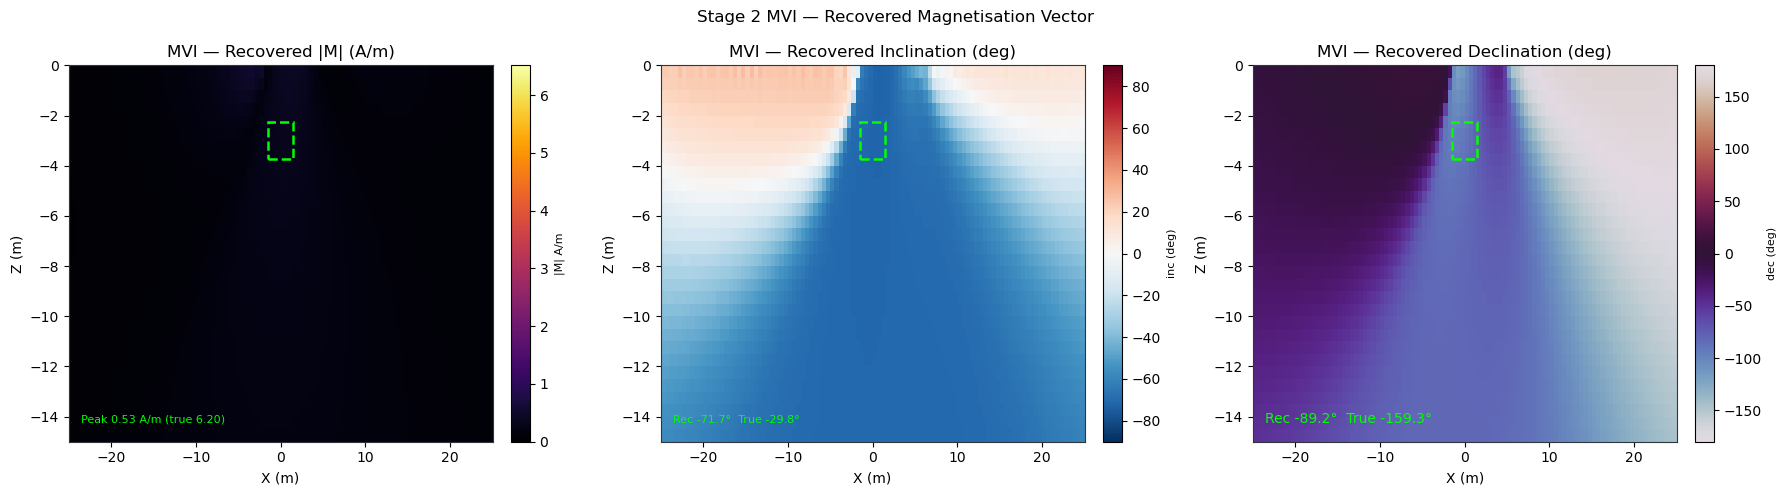

In [398]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# |M| amplitude
ax = axes[0]; sax(ax)
im = ax.pcolormesh(xc, zc, crop(M_amp_rec), cmap="inferno",
    vmin=0, vmax=M_amp_uxo*1.05, shading="auto")
uxo_box(ax); ax.set_xlim(-25,25); ax.set_ylim(-15,0)
ax.set_xlabel("X (m)", color="k"); ax.set_ylabel("Z (m)", color="k")
ax.set_title("MVI — Recovered |M| (A/m)", color="k")
cbar(fig, ax, im, "|M| A/m")
ax.text(.03,.05,f"Peak {M_amp_rec.max():.2f} A/m (true {M_amp_uxo:.2f})",
    transform=ax.transAxes, color="lime", fontsize=8)


# Inclination
ax = axes[1]; sax(ax)
im = ax.pcolormesh(xc, zc, crop(inc_rec), cmap="RdBu_r", vmin=-90, vmax=90, shading="auto")
uxo_box(ax); ax.set_xlim(-25,25); ax.set_ylim(-15,0)
ax.set_xlabel("X (m)", color="k"); ax.set_ylabel("Z (m)", color="k")
ax.set_title("MVI — Recovered Inclination (deg)", color="k")
cbar(fig, ax, im, "inc (deg)")
ax.text(.03,.05,f"Rec {inc_rec[in_uxo].mean():.1f}°  True {inc_true[in_uxo].mean():.1f}°",
    transform=ax.transAxes, color="lime", fontsize=8)

# Declination
ax = axes[2]; sax(ax)
im = ax.pcolormesh(xc, zc, crop(dec_rec), cmap="twilight", vmin=-180, vmax=180, shading="auto")
uxo_box(ax); ax.set_xlim(-25,25); ax.set_ylim(-15,0)
ax.set_xlabel("X (m)", color="k"); ax.set_ylabel("Z (m)", color="k")
ax.set_title("MVI — Recovered Declination (deg)", color="k")
cbar(fig, ax, im, "dec (deg)")
ax.text(.03,.05,f"Rec {dec_rec[in_uxo].mean():.1f}°  True {dec_true[in_uxo].mean():.1f}°",
    transform=ax.transAxes, color="lime")

fig.suptitle("Stage 2 MVI — Recovered Magnetisation Vector", color="k", fontsize=12)
plt.tight_layout(); plt.show()


## 14. Final summary

In [399]:
print("=" * 65)
print("TWO-STAGE MVI — FINAL SUMMARY")
print("=" * 65)
print(f"  Observations                      : {n_rx}")
print()
print(f"  STAGE 1 (Scalar chi inversion)")
print(f"    Final phi_d                     : {phi_d_sc[-1]:.2f}  (target ~{n_rx})")
print(f"    Iterations                      : {len(it1)}")
print(f"    Obs vs Pred R²                  : {r2_sc:.4f}")
print(f"    Peak recovered chi              : {m_sc.max():.5f}  (true {chi_uxo})")
print()
print(f"  STAGE 2 (MVI — full vector model)")
print(f"    Final phi_d                     : {phi_d_mvi[-1]:.2f}  (target ~{n_rx})")
print(f"    Iterations                      : {len(it2)}")
print(f"    Obs vs Pred R²                  : {r2_mvi:.4f}")
print(f"    Peak |M| recovered              : {M_amp_rec.max():.3f} A/m")
print(f"    True |M| in UXO                 : {M_amp_uxo:.3f} A/m")
print(f"    UXO inc  recovered / true       : {inc_rec[in_uxo].mean():.1f}° / {inc_true[in_uxo].mean():.1f}°")
print(f"    UXO dec  recovered / true       : {dec_rec[in_uxo].mean():.1f}° / {dec_true[in_uxo].mean():.1f}°")



TWO-STAGE MVI — FINAL SUMMARY
  Observations                      : 101

  STAGE 1 (Scalar chi inversion)
    Final phi_d                     : 99.32  (target ~101)
    Iterations                      : 23
    Obs vs Pred R²                  : 0.9995
    Peak recovered chi              : 0.69333  (true 0.05)

  STAGE 2 (MVI — full vector model)
    Final phi_d                     : 256.35  (target ~101)
    Iterations                      : 40
    Obs vs Pred R²                  : 0.9949
    Peak |M| recovered              : 0.534 A/m
    True |M| in UXO                 : 6.205 A/m
    UXO inc  recovered / true       : -71.7° / -29.8°
    UXO dec  recovered / true       : -89.2° / -159.3°


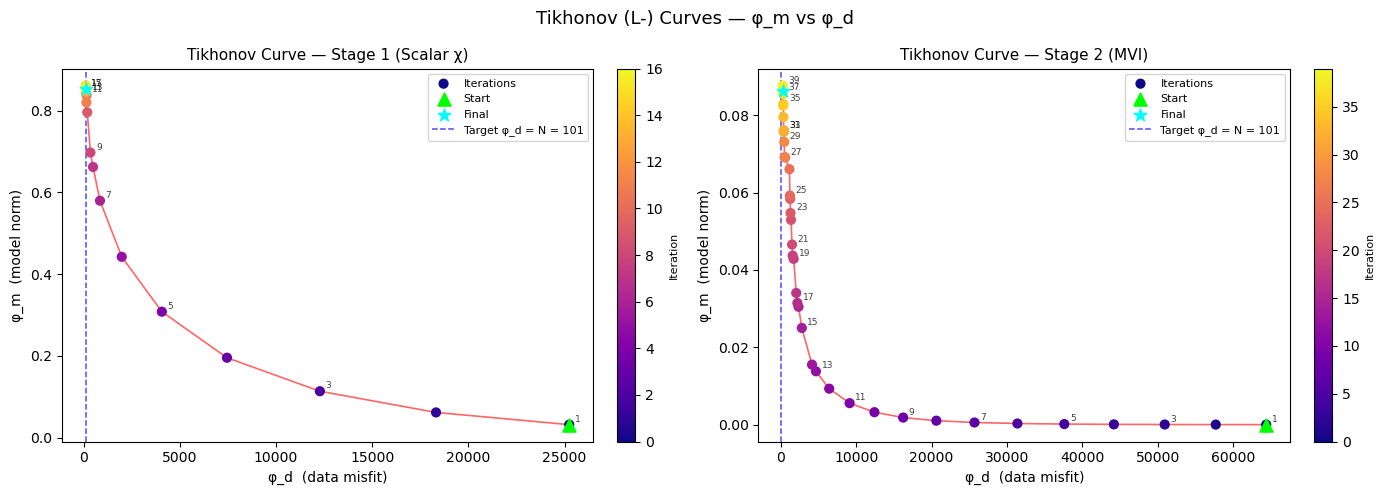

In [400]:
# ── Tikhonov Curves (L-curves) — Stage 1 & Stage 2 ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Helper: annotate every 5th iteration ─────────────────────────────────────
def annotate_iters(ax, phi_d, phi_m, color, step=2):
    for i in range(0, len(phi_d), step):
        ax.annotate(str(i + 1), (phi_d[i], phi_m[i]),
                    fontsize=6.5, color=color, alpha=0.75,
                    xytext=(4, 2), textcoords="offset points")

# ── Stage 1 scalar Tikhonov curve ────────────────────────────────────────────
ax = axes[0]
ax.tick_params(colors="k")

sc1 = ax.scatter(phi_d_sc, phi_m_sc,
                 c=np.arange(len(phi_d_sc)), cmap="plasma",
                 s=40, zorder=5, label="Iterations")
ax.plot(phi_d_sc, phi_m_sc, color="red", lw=1.2, alpha=0.6)
ax.scatter(phi_d_sc[0],  phi_m_sc[0],  s=90, marker="^",
           color="lime",    zorder=6, label="Start")
ax.scatter(phi_d_sc[-1], phi_m_sc[-1], s=90, marker="*",
           color="cyan",    zorder=6, label="Final")
ax.axvline(n_rx, color="blue", lw=1.1, ls="--", alpha=0.7,
           label=f"Target φ_d = N = {n_rx}")
annotate_iters(ax, phi_d_sc, phi_m_sc, "k")
cb1 = fig.colorbar(sc1, ax=ax, fraction=0.046, pad=0.04)
cb1.set_label("Iteration", color="k", fontsize=8)
cb1.ax.yaxis.set_tick_params(color="k")
plt.setp(cb1.ax.yaxis.get_ticklabels(), color="k")
ax.set_xlabel("φ_d  (data misfit)", color="k")
ax.set_ylabel("φ_m  (model norm)", color="k")
ax.set_title("Tikhonov Curve — Stage 1 (Scalar χ)", color="k", fontsize=11)
ax.legend(fontsize=8, labelcolor="k")

# ── Stage 2 MVI Tikhonov curve ───────────────────────────────────────────────
ax = axes[1]


sc2 = ax.scatter(phi_d_mvi, phi_m_mvi,
                 c=np.arange(len(phi_d_mvi)), cmap="plasma",
                 s=40, zorder=5, label="Iterations")
ax.plot(phi_d_mvi, phi_m_mvi, color="red", lw=1.2, alpha=0.6)
ax.scatter(phi_d_mvi[0],  phi_m_mvi[0],  s=90, marker="^",
           color="lime",    zorder=6, label="Start")
ax.scatter(phi_d_mvi[-1], phi_m_mvi[-1], s=90, marker="*",
           color="cyan",    zorder=6, label="Final")
ax.axvline(n_rx, color="blue", lw=1.1, ls="--", alpha=0.7,
           label=f"Target φ_d = N = {n_rx}")
annotate_iters(ax, phi_d_mvi, phi_m_mvi, "k")
cb2 = fig.colorbar(sc2, ax=ax, fraction=0.046, pad=0.04)
cb2.set_label("Iteration", color="k", fontsize=8)
cb2.ax.yaxis.set_tick_params(color="k")
plt.setp(cb2.ax.yaxis.get_ticklabels(), color="k")
ax.set_xlabel("φ_d  (data misfit)", color="k")
ax.set_ylabel("φ_m  (model norm)", color="k")
ax.set_title("Tikhonov Curve — Stage 2 (MVI)", color="k", fontsize=11)
ax.legend(fontsize=8, labelcolor="k")

fig.suptitle("Tikhonov (L-) Curves — φ_m vs φ_d", color="k",
             fontsize=13)
plt.tight_layout()
plt.show()

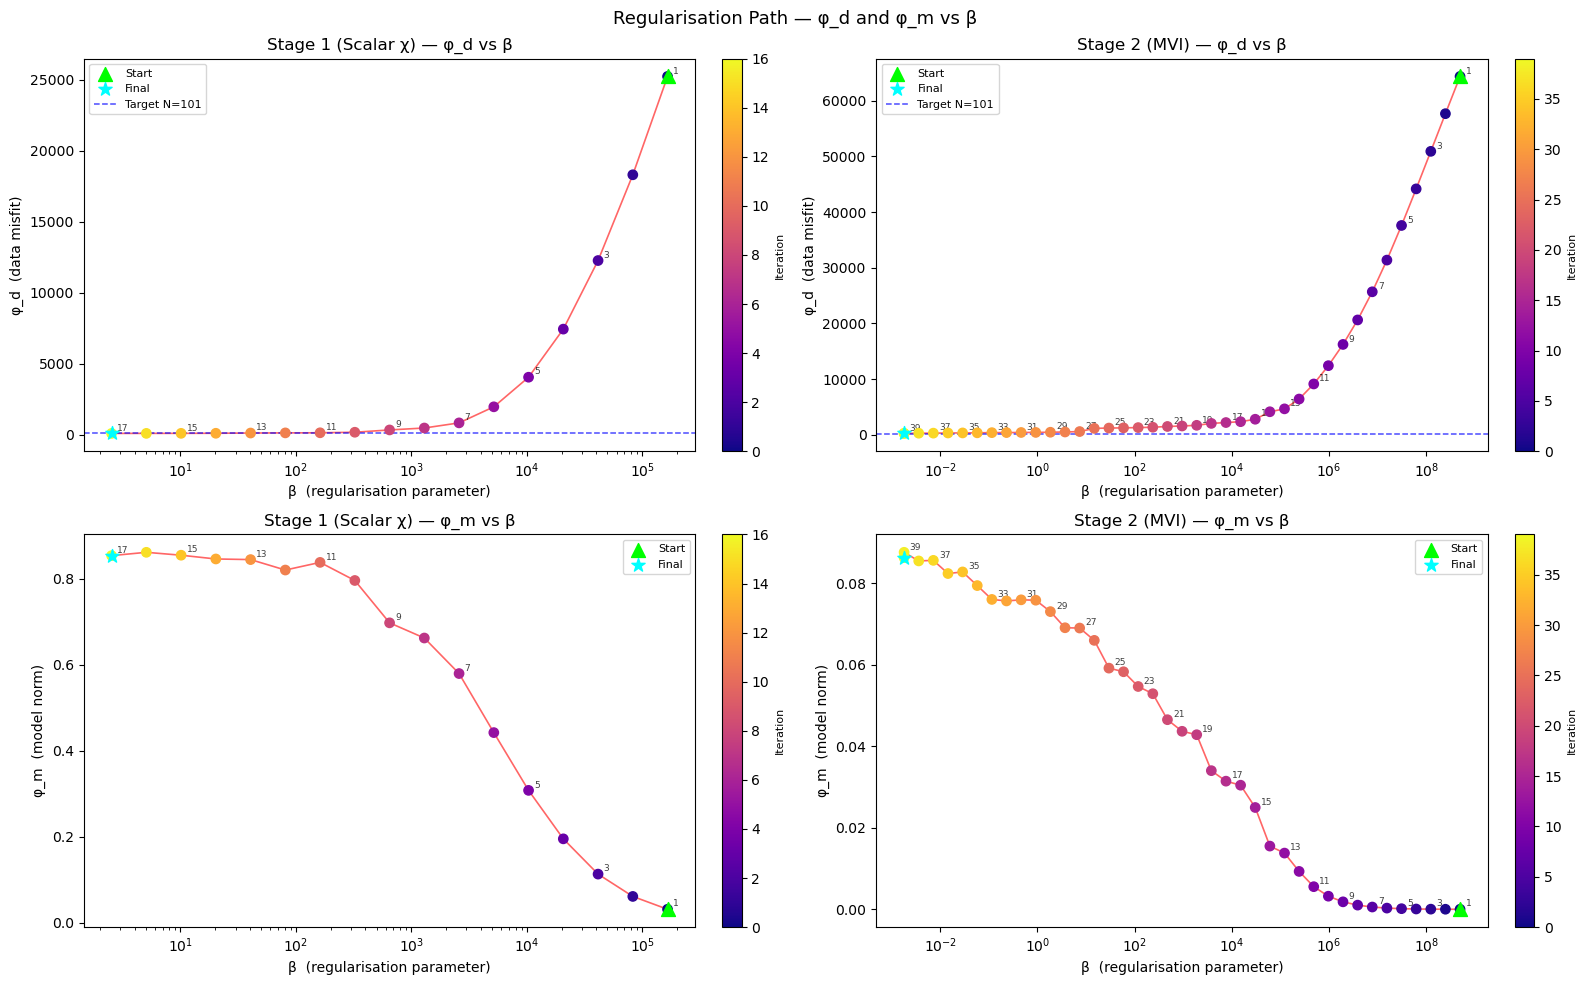

In [401]:
beta_sc  = np.array(dl_sc[3].beta)
beta_mvi = np.array(dl_mvi[3].beta)

phi_d_sc  = np.array(dl_sc[3].phi_d)
phi_m_sc  = np.array(dl_sc[3].phi_m)
phi_d_mvi = np.array(dl_mvi[3].phi_d)
phi_m_mvi = np.array(dl_mvi[3].phi_m)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))


def style_ax(ax):
    ax.tick_params(colors="k")
    ax.xaxis.label.set_color("k")
    ax.yaxis.label.set_color("k")
    ax.title.set_color("k")

def annotate_iters_beta(ax, beta, phi, color, step=2):
    for i in range(0, len(beta), step):
        ax.annotate(str(i + 1), (beta[i], phi[i]),
                    fontsize=6.5, color=color, alpha=0.75,
                    xytext=(4, 2), textcoords="offset points")

# ── [0,0] Stage 1: φ_d vs β ──────────────────────────────────────────────────
ax = axes[0, 0]; style_ax(ax)
sc = ax.scatter(beta_sc, phi_d_sc, c=np.arange(len(beta_sc)),
                cmap="plasma", s=45, zorder=5)
ax.plot(beta_sc, phi_d_sc, color="red", lw=1.2, alpha=0.6)
ax.scatter(beta_sc[0],  phi_d_sc[0],  s=100, marker="^", color="lime",  zorder=6, label="Start")
ax.scatter(beta_sc[-1], phi_d_sc[-1], s=100, marker="*", color="cyan",  zorder=6, label="Final")
ax.axhline(n_rx, color="blue", lw=1.1, ls="--", alpha=0.7, label=f"Target N={n_rx}")
annotate_iters_beta(ax, beta_sc, phi_d_sc, "k")
ax.set_xscale("log")
ax.set_xlabel("β  (regularisation parameter)")
ax.set_ylabel("φ_d  (data misfit)")
ax.set_title("Stage 1 (Scalar χ) — φ_d vs β")
ax.legend(fontsize=8, labelcolor="k")
fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04).set_label("Iteration", color="k", fontsize=8)

# ── [0,1] Stage 2: φ_d vs β ──────────────────────────────────────────────────
ax = axes[0, 1]; style_ax(ax)
sc = ax.scatter(beta_mvi, phi_d_mvi, c=np.arange(len(beta_mvi)),
                cmap="plasma", s=45, zorder=5)
ax.plot(beta_mvi, phi_d_mvi, color="red", lw=1.2, alpha=0.6)
ax.scatter(beta_mvi[0],  phi_d_mvi[0],  s=100, marker="^", color="lime",  zorder=6, label="Start")
ax.scatter(beta_mvi[-1], phi_d_mvi[-1], s=100, marker="*", color="cyan",  zorder=6, label="Final")
ax.axhline(n_rx, color="blue", lw=1.1, ls="--", alpha=0.7, label=f"Target N={n_rx}")
annotate_iters_beta(ax, beta_mvi, phi_d_mvi, "k")
ax.set_xscale("log")
ax.set_xlabel("β  (regularisation parameter)")
ax.set_ylabel("φ_d  (data misfit)")
ax.set_title("Stage 2 (MVI) — φ_d vs β")
ax.legend(fontsize=8, labelcolor="k")
fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04).set_label("Iteration", color="k", fontsize=8)

# ── [1,0] Stage 1: φ_m vs β ──────────────────────────────────────────────────
ax = axes[1, 0]; style_ax(ax)
sc = ax.scatter(beta_sc, phi_m_sc, c=np.arange(len(beta_sc)),
                cmap="plasma", s=45, zorder=5)
ax.plot(beta_sc, phi_m_sc, color="red", lw=1.2, alpha=0.6)
ax.scatter(beta_sc[0],  phi_m_sc[0],  s=100, marker="^", color="lime",  zorder=6, label="Start")
ax.scatter(beta_sc[-1], phi_m_sc[-1], s=100, marker="*", color="cyan",  zorder=6, label="Final")
annotate_iters_beta(ax, beta_sc, phi_m_sc, "k")
ax.set_xscale("log")
ax.set_xlabel("β  (regularisation parameter)")
ax.set_ylabel("φ_m  (model norm)")
ax.set_title("Stage 1 (Scalar χ) — φ_m vs β")
ax.legend(fontsize=8, labelcolor="k")
fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04).set_label("Iteration", color="k", fontsize=8)

# ── [1,1] Stage 2: φ_m vs β ──────────────────────────────────────────────────
ax = axes[1, 1]; style_ax(ax)
sc = ax.scatter(beta_mvi, phi_m_mvi, c=np.arange(len(beta_mvi)),
                cmap="plasma", s=45, zorder=5)
ax.plot(beta_mvi, phi_m_mvi, color="red", lw=1.2, alpha=0.6)
ax.scatter(beta_mvi[0],  phi_m_mvi[0],  s=100, marker="^", color="lime",  zorder=6, label="Start")
ax.scatter(beta_mvi[-1], phi_m_mvi[-1], s=100, marker="*", color="cyan",  zorder=6, label="Final")
annotate_iters_beta(ax, beta_mvi, phi_m_mvi, "k")
ax.set_xscale("log")
ax.set_xlabel("β  (regularisation parameter)")
ax.set_ylabel("φ_m  (model norm)")
ax.set_title("Stage 2 (MVI) — φ_m vs β")
ax.legend(fontsize=8, labelcolor="k")
fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04).set_label("Iteration", color="k", fontsize=8)

fig.suptitle("Regularisation Path — φ_d and φ_m vs β", color="k", fontsize=13)
plt.tight_layout()
plt.show()

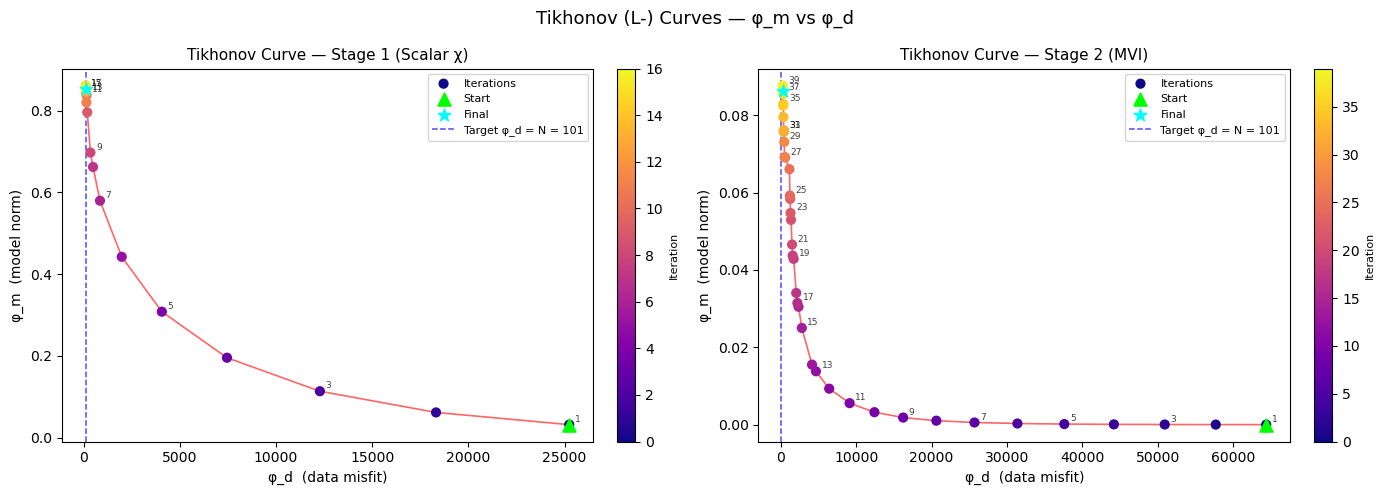

In [402]:
# ── Tikhonov Curves (L-curves) — Stage 1 & Stage 2 ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Helper: annotate every 5th iteration ─────────────────────────────────────
def annotate_iters(ax, phi_d, phi_m, color, step=2):
    for i in range(0, len(phi_d), step):
        ax.annotate(str(i + 1), (phi_d[i], phi_m[i]),
                    fontsize=6.5, color=color, alpha=0.75,
                    xytext=(4, 2), textcoords="offset points")

# ── Stage 1 scalar Tikhonov curve ────────────────────────────────────────────
ax = axes[0]
ax.tick_params(colors="k")

sc1 = ax.scatter(phi_d_sc, phi_m_sc,
                 c=np.arange(len(phi_d_sc)), cmap="plasma",
                 s=40, zorder=5, label="Iterations")
ax.plot(phi_d_sc, phi_m_sc, color="red", lw=1.2, alpha=0.6)
ax.scatter(phi_d_sc[0],  phi_m_sc[0],  s=90, marker="^",
           color="lime",    zorder=6, label="Start")
ax.scatter(phi_d_sc[-1], phi_m_sc[-1], s=90, marker="*",
           color="cyan",    zorder=6, label="Final")
ax.axvline(n_rx, color="blue", lw=1.1, ls="--", alpha=0.7,
           label=f"Target φ_d = N = {n_rx}")
annotate_iters(ax, phi_d_sc, phi_m_sc, "k")
cb1 = fig.colorbar(sc1, ax=ax, fraction=0.046, pad=0.04)
cb1.set_label("Iteration", color="k", fontsize=8)
cb1.ax.yaxis.set_tick_params(color="k")
plt.setp(cb1.ax.yaxis.get_ticklabels(), color="k")
ax.set_xlabel("φ_d  (data misfit)", color="k")
ax.set_ylabel("φ_m  (model norm)", color="k")
ax.set_title("Tikhonov Curve — Stage 1 (Scalar χ)", color="k", fontsize=11)
ax.legend(fontsize=8, labelcolor="k")

# ── Stage 2 MVI Tikhonov curve ───────────────────────────────────────────────
ax = axes[1]


sc2 = ax.scatter(phi_d_mvi, phi_m_mvi,
                 c=np.arange(len(phi_d_mvi)), cmap="plasma",
                 s=40, zorder=5, label="Iterations")
ax.plot(phi_d_mvi, phi_m_mvi, color="red", lw=1.2, alpha=0.6)
ax.scatter(phi_d_mvi[0],  phi_m_mvi[0],  s=90, marker="^",
           color="lime",    zorder=6, label="Start")
ax.scatter(phi_d_mvi[-1], phi_m_mvi[-1], s=90, marker="*",
           color="cyan",    zorder=6, label="Final")
ax.axvline(n_rx, color="blue", lw=1.1, ls="--", alpha=0.7,
           label=f"Target φ_d = N = {n_rx}")
annotate_iters(ax, phi_d_mvi, phi_m_mvi, "k")
cb2 = fig.colorbar(sc2, ax=ax, fraction=0.046, pad=0.04)
cb2.set_label("Iteration", color="k", fontsize=8)
cb2.ax.yaxis.set_tick_params(color="k")
plt.setp(cb2.ax.yaxis.get_ticklabels(), color="k")
ax.set_xlabel("φ_d  (data misfit)", color="k")
ax.set_ylabel("φ_m  (model norm)", color="k")
ax.set_title("Tikhonov Curve — Stage 2 (MVI)", color="k", fontsize=11)
ax.legend(fontsize=8, labelcolor="k")

fig.suptitle("Tikhonov (L-) Curves — φ_m vs φ_d", color="k",
             fontsize=13)
plt.tight_layout()
plt.show()